Mount Drive and Install Libraries


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import subprocess
subprocess.run(['pip', 'install', 'wordcloud', 'gensim', 'gradio', '-q'])

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',   quiet=True)

Mounted at /content/drive


True

Imports

In [ ]:
import os
import re
import time
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, SimpleRNN, LSTM,
                                     Dense, Dropout)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score)
from sklearn.preprocessing import LabelEncoder

print('TensorFlow version :', tf.__version__)
print('GPU Available      :', tf.config.list_physical_devices('GPU'))

TensorFlow version : 2.20.0
GPU Available      : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


 Load Dataset

In [ ]:
csv_file = '/content/drive/MyDrive/AI ML/4. Hate Speech Detection Dataset-20260503T122512Z-3-001/4. Hate Speech Detection Dataset/hatevsoffensive_language.csv'
df       = pd.read_csv(csv_file)

print('Dataset Shape  :', df.shape)
print('Column Names   :', list(df.columns))
print('Label Values   :', df['label'].unique())
print()
print(df.head(3))
print()
print('Missing Values :')
print(df.isnull().sum())

Dataset Shape  : (24783, 2)
Column Names   : ['label', 'text']
Label Values   : ['neither' 'offensive language' 'hate speec']

                label                                               text
0             neither  !!! RT @mayasolovely: As a woman you shouldn't...
1  offensive language  !!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2  offensive language  !!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...

Missing Values :
label    0
text     0
dtype: int64


Class Distribution Plot


Label Distribution:
label
offensive language    19190
neither                4163
hate speec             1430
Name: count, dtype: int64


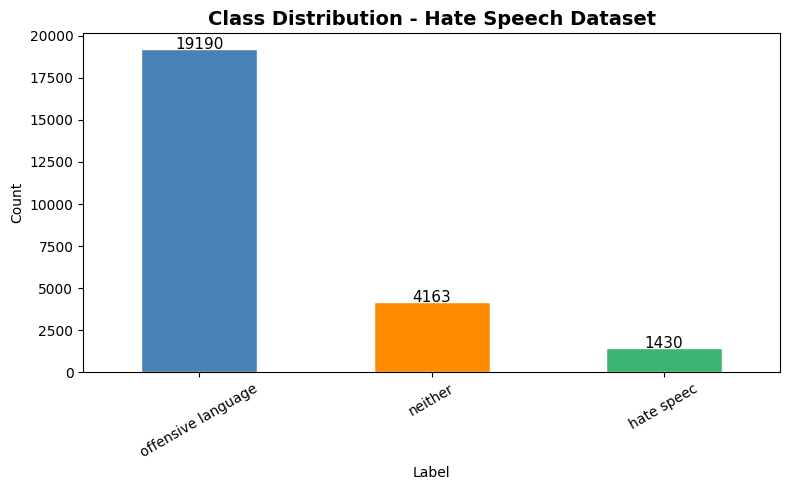

In [ ]:
print('Label Distribution:')
print(df['label'].value_counts())

fig, ax = plt.subplots(figsize=(8, 5))
df['label'].value_counts().plot(
    kind='bar', ax=ax,
    color=['steelblue', 'darkorange', 'mediumseagreen'],
    edgecolor='white'
)
ax.set_title('Class Distribution - Hate Speech Dataset',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Label')
ax.set_ylabel('Count')
plt.xticks(rotation=30)

for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2.0,
        bar.get_height() + 20,
        str(int(bar.get_height())),
        ha='center', fontsize=11
    )

plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150)
plt.show()

Text Cleaning

In [ ]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'&amp;', 'and', text)
    text = re.sub(r"can't", 'cannot', text)
    text = re.sub(r"won't", 'will not', text)
    text = re.sub(r"n't", ' not', text)
    text = re.sub(r"'re", ' are', text)
    text = re.sub(r"'s", ' is', text)
    text = re.sub(r"'d", ' would', text)
    text = re.sub(r"'ll", ' will', text)
    text = re.sub(r"'ve", ' have', text)
    text = re.sub(r"'m", ' am', text)
    text = re.sub(r'[^\w\s]', '', text)
    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()
    tokens     = text.split()
    tokens     = [lemmatizer.lemmatize(w) for w in tokens
                  if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

df['cleaned_text'] = df['text'].apply(clean_text)

print('Text cleaning complete')
print()
for i in range(3):
    print(f'Original : {df["text"].iloc[i][:80]}')
    print(f'Cleaned  : {df["cleaned_text"].iloc[i][:80]}')
    print()

Text cleaning complete

Original : !!! RT @mayasolovely: As a woman you shouldn't complain about cleaning up your h
Cleaned  : woman complain cleaning house man always take trash

Original : !!!!! RT @mleew17: boy dats cold...tyga dwn bad for cuffin dat hoe in the 1st pl
Cleaned  : boy dat coldtyga dwn bad cuffin dat hoe place

Original : !!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby4life: You ever fuck a bitch and s
Cleaned  : dawg ever fuck bitch start cry confused shit



Word Cloud and Top Words

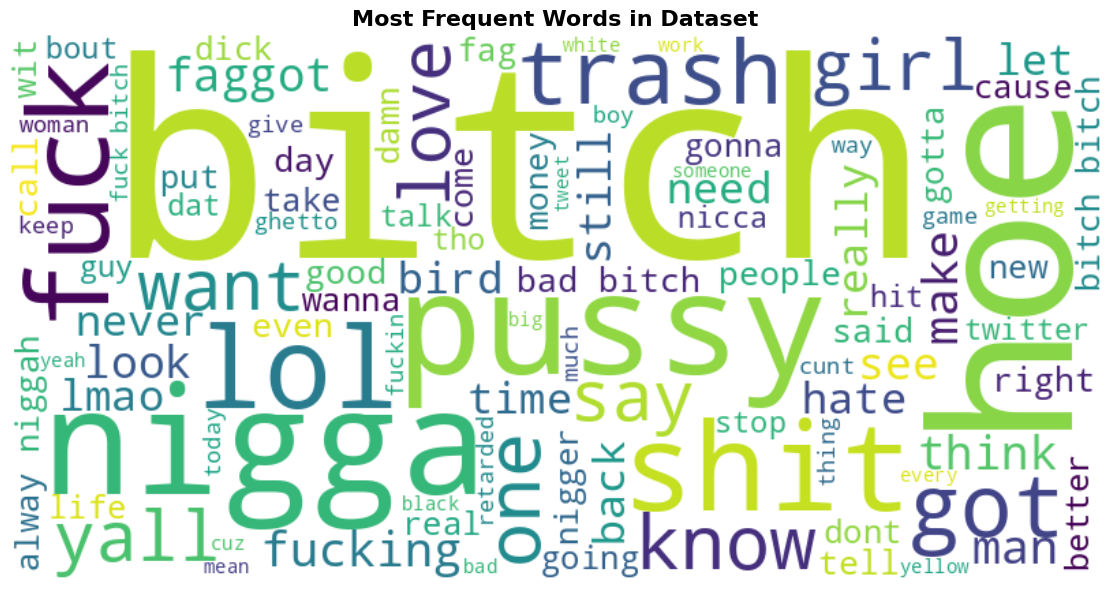

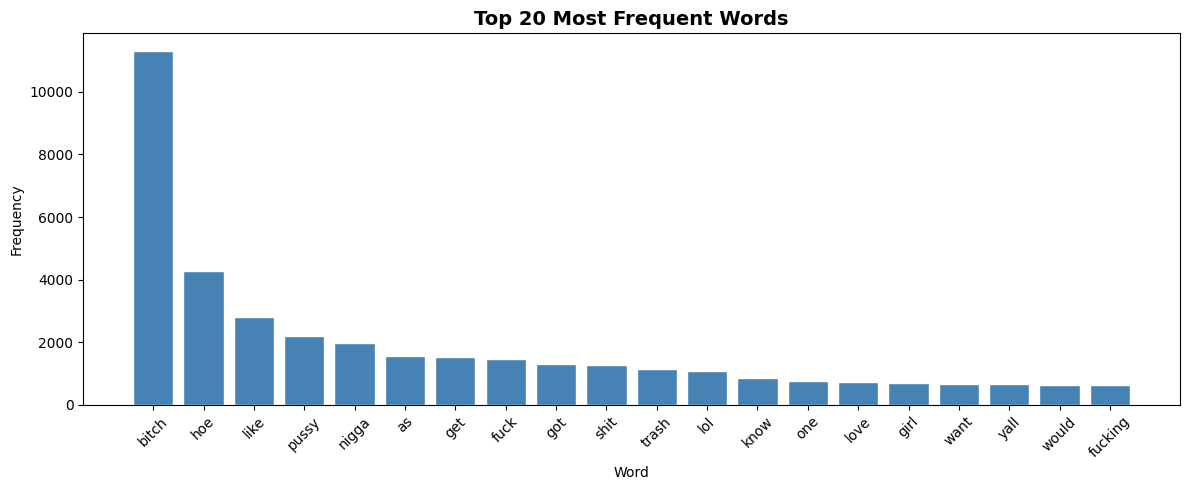

In [ ]:
all_text  = ' '.join(df['cleaned_text'].values)
wordcloud = WordCloud(
    width=800, height=400,
    background_color='white',
    colormap='viridis',
    max_words=100
).generate(all_text)

plt.figure(figsize=(14, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words in Dataset',
          fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('wordcloud.png', dpi=150)
plt.show()

word_freq = Counter(all_text.split())
top_words = word_freq.most_common(20)
words     = [w[0] for w in top_words]
counts    = [w[1] for w in top_words]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(words, counts, color='steelblue', edgecolor='white')
ax.set_title('Top 20 Most Frequent Words',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Word')
ax.set_ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('top_words.png', dpi=150)
plt.show()

Label Encoding and Train Test Split

In [ ]:
le      = LabelEncoder()
y       = le.fit_transform(df['label'].values)
classes = list(le.classes_)

print('Label encoding    :', dict(zip(classes, le.transform(classes))))
print('Number of classes :', len(classes))

texts = df['cleaned_text'].values

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    texts, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Train size : {len(X_train_raw)}')
print(f'Test size  : {len(X_test_raw)}')

Label encoding    : {'hate speec': np.int64(0), 'neither': np.int64(1), 'offensive language': np.int64(2)}
Number of classes : 3
Train size : 19826
Test size  : 4957


Tokenization and Padding

In [ ]:
VOCAB_SIZE = 10000
EMBED_DIM  = 64

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train_raw)

train_seq = tokenizer.texts_to_sequences(X_train_raw)
test_seq  = tokenizer.texts_to_sequences(X_test_raw)

lengths = [len(s) for s in train_seq]
MAX_LEN = int(np.percentile(lengths, 95))
print(f'95th percentile sequence length : {MAX_LEN}')

X_train_pad = pad_sequences(
    train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(
    test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f'X_train_pad shape : {X_train_pad.shape}')
print(f'X_test_pad shape  : {X_test_pad.shape}')

95th percentile sequence length : 13
X_train_pad shape : (19826, 13)
X_test_pad shape  : (4957, 13)


Helper Functions

In [ ]:
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history.history['accuracy'],     label='Train')
    axes[0].plot(history.history['val_accuracy'], label='Validation')
    axes[0].set_title(f'{title} - Accuracy', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()

    axes[1].plot(history.history['loss'],     label='Train')
    axes[1].plot(history.history['val_loss'], label='Validation')
    axes[1].set_title(f'{title} - Loss', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(f'{title.replace(" ", "_")}_curves.png', dpi=150)
    plt.show()


def evaluate_model(model, X_test, y_test, classes, title):
    y_pred_probs = model.predict(X_test, verbose=1)
    y_pred       = np.argmax(y_pred_probs, axis=1)
    acc          = accuracy_score(y_test, y_pred)

    print(f'Evaluation Report : {title}')
    print(f'Test Accuracy     : {acc * 100:.2f}%')
    print(classification_report(y_test, y_pred, target_names=classes))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix - {title}',
              fontsize=14, fontweight='bold')
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=30, fontsize=10)
    plt.yticks(tick_marks, classes, fontsize=10)
    thresh = cm.max() / 2.0
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha='center', va='center',
                 color='white' if cm[i, j] > thresh else 'black',
                 fontsize=9)
    plt.ylabel('True Label',      fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'{title.replace(" ", "_")}_cm.png', dpi=150)
    plt.show()

    return y_pred, acc

print('Helper functions defined successfully')

Helper functions defined successfully


Build Simple RNN

In [ ]:
NUM_CLASSES = len(classes)

model_rnn = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM),
    SimpleRNN(64, return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(NUM_CLASSES, activation='softmax')
], name='Simple_RNN')

model_rnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_rnn.build(input_shape=(None, MAX_LEN))
model_rnn.summary()

Model: "Simple_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 13, 64)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 650,435 (2.48 MB)

 Trainable params: 650,435 (2.48 MB)

 Non-trainable params: 0 (0.00 B)

Train Simple RNN

Epoch 1/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.8225 - loss: 0.5016 - val_accuracy: 0.8875 - val_loss: 0.3284 - learning_rate: 0.0010
Epoch 2/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9078 - loss: 0.2692 - val_accuracy: 0.8875 - val_loss: 0.3032 - learning_rate: 0.0010
Epoch 3/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9344 - loss: 0.1939 - val_accuracy: 0.8845 - val_loss: 0.3304 - learning_rate: 0.0010
Epoch 4/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9561 - loss: 0.1322 - val_accuracy: 0.8729 - val_loss: 0.3869 - learning_rate: 0.0010
Epoch 5/20
276/279 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9716 - loss: 0.0909
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
279/279 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9687 - loss: 0.0968 - val_accuracy: 0.8729 - val_loss: 0.4511 - learning_rate: 0.0010
Epoch 6/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9809 - loss: 0.0583 - 

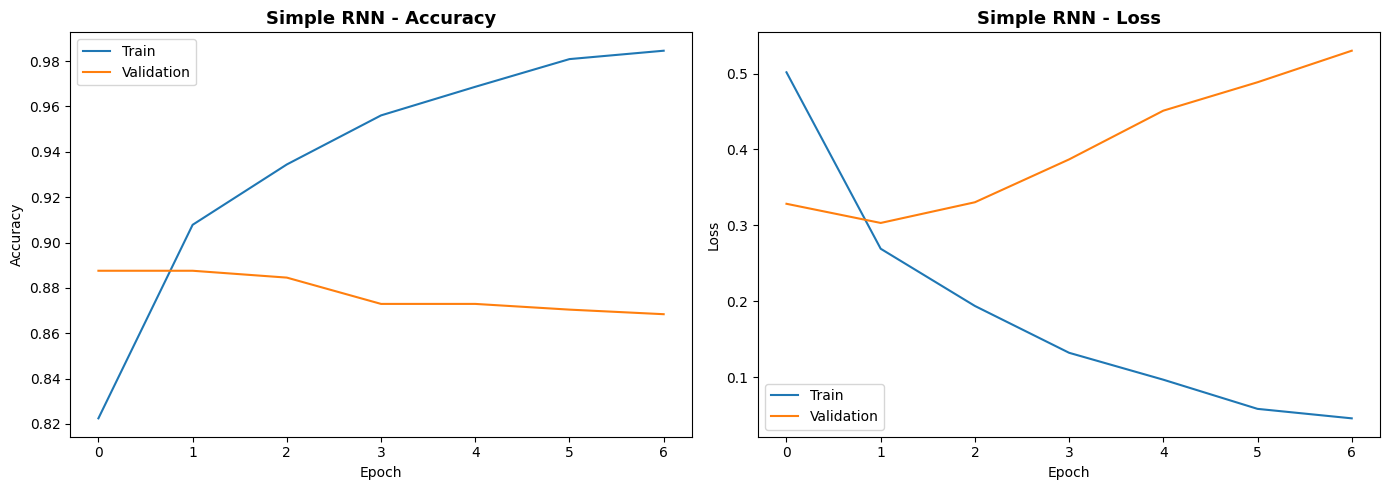

155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
Evaluation Report : Simple RNN
Test Accuracy     : 88.32%
                    precision    recall  f1-score   support

        hate speec       0.44      0.18      0.25       286
           neither       0.79      0.84      0.81       833
offensive language       0.92      0.95      0.93      3838

          accuracy                           0.88      4957
         macro avg       0.72      0.65      0.67      4957
      weighted avg       0.87      0.88      0.87      4957



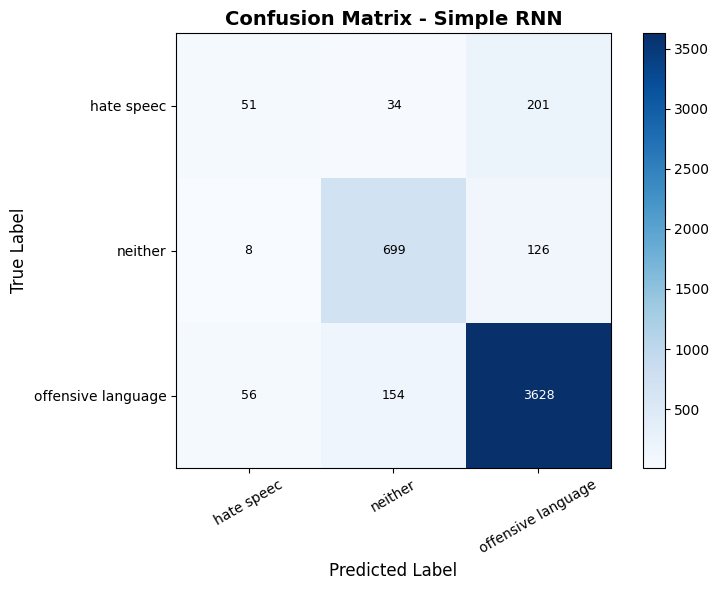

Simple RNN model saved


In [ ]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                     patience=3, min_lr=1e-6, verbose=1)
]

start_time  = time.time()
history_rnn = model_rnn.fit(
    X_train_pad, y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)
rnn_time = time.time() - start_time

print(f'Simple RNN training time : {rnn_time:.1f} seconds')
plot_history(history_rnn, 'Simple RNN')
y_pred_rnn, acc_rnn = evaluate_model(
    model_rnn, X_test_pad, y_test, classes, 'Simple RNN')
model_rnn.save('model_rnn.h5')
print('Simple RNN model saved')

Build LSTM

In [ ]:
model_lstm = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM),
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(NUM_CLASSES, activation='softmax')
], name='LSTM_Trainable_Embedding')

model_lstm.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_lstm.build(input_shape=(None, MAX_LEN))
model_lstm.summary()

Model: "LSTM_Trainable_Embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 13, 64)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 675,203 (2.58 MB)

 Trainable params: 675,203 (2.58 MB)

 Non-trainable params: 0 (0.00 B)

 Train LSTM

Epoch 1/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9132 - loss: 0.2736 - val_accuracy: 0.8810 - val_loss: 0.3380 - learning_rate: 5.0000e-04
Epoch 2/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9223 - loss: 0.2424 - val_accuracy: 0.8845 - val_loss: 0.3571 - learning_rate: 5.0000e-04
Epoch 3/20
275/279 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9276 - loss: 0.2305
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
279/279 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9279 - loss: 0.2224 - val_accuracy: 0.8800 - val_loss: 0.3633 - learning_rate: 5.0000e-04
Epoch 4/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9321 - loss: 0.2034 - val_accuracy: 0.8810 - val_loss: 0.3784 - learning_rate: 2.5000e-04
Epoch 5/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9328 - loss: 0.1969 - val_accuracy: 0.8754 - val_loss: 0.4089 - learning_rate: 2.5000e-04
Epoch 5: early stopping
Restoring model weights from the end of the 

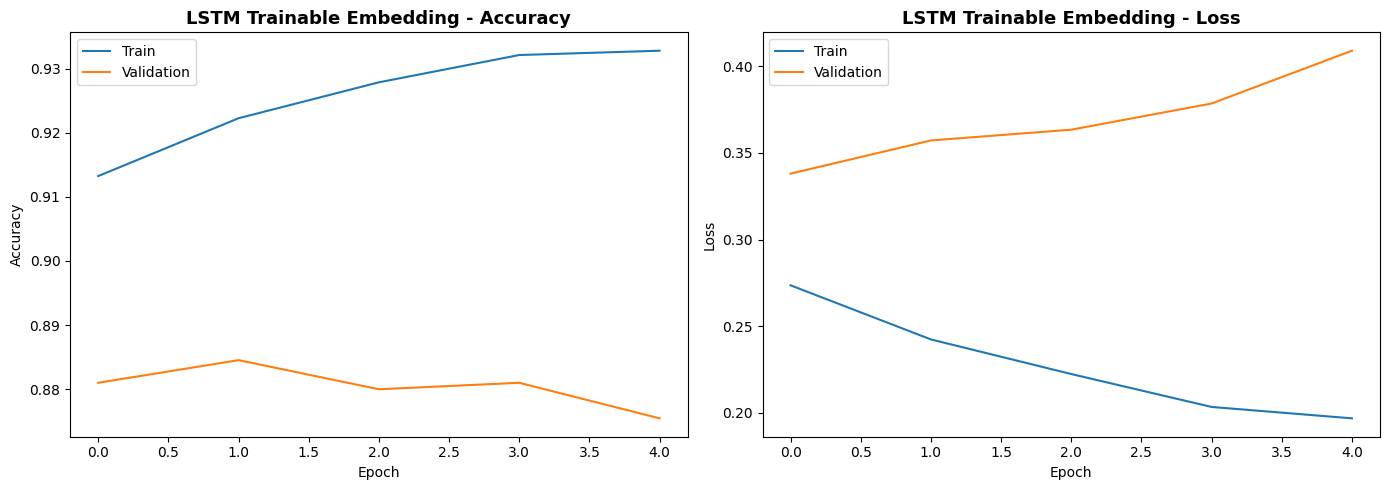

155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Evaluation Report : LSTM Trainable Embedding
Test Accuracy     : 88.18%
                    precision    recall  f1-score   support

        hate speec       0.00      0.00      0.00       286
           neither       0.83      0.77      0.80       833
offensive language       0.89      0.97      0.93      3838

          accuracy                           0.88      4957
         macro avg       0.57      0.58      0.58      4957
      weighted avg       0.83      0.88      0.85      4957



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


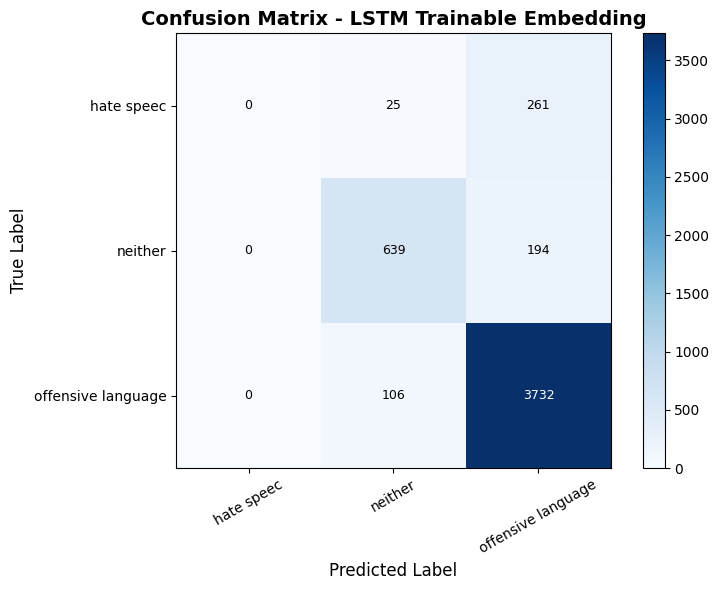

LSTM model saved


In [ ]:
start_time   = time.time()
history_lstm = model_lstm.fit(
    X_train_pad, y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)
lstm_time = time.time() - start_time

print(f'LSTM training time : {lstm_time:.1f} seconds')
plot_history(history_lstm, 'LSTM Trainable Embedding')
y_pred_lstm, acc_lstm = evaluate_model(
    model_lstm, X_test_pad, y_test, classes, 'LSTM Trainable Embedding')
model_lstm.save('model_lstm.h5')
print('LSTM model saved')

 Download GloVe Embeddings

In [ ]:
import gensim.downloader as api

print('Downloading GloVe Twitter 50d embeddings...')
print('This will take 3 to 5 minutes on first run...')
embedding_model = api.load('glove-twitter-50')
print('GloVe embeddings loaded successfully')

word_index    = tokenizer.word_index
EMBED_DIM_W2V = 50

embedding_matrix = np.zeros((VOCAB_SIZE, EMBED_DIM_W2V))
found = 0

for word, i in word_index.items():
    if i < VOCAB_SIZE:
        if word in embedding_model:
            embedding_matrix[i] = embedding_model[word]
            found += 1

print(f'Words found in GloVe : {found} out of {min(len(word_index), VOCAB_SIZE)}')

This will take 3 to 5 minutes on first run...
GloVe embeddings loaded successfully
Words found in GloVe : 9025 out of 10000


 Build LSTM with GloVe

In [ ]:
EMBED_DIM_W2V = 50

model_lstm_glove = Sequential([
    Embedding(input_dim=VOCAB_SIZE,
              output_dim=EMBED_DIM_W2V,
              weights=[embedding_matrix],
              trainable=False),
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(NUM_CLASSES, activation='softmax')
], name='LSTM_GloVe_Embedding')

model_lstm_glove.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_lstm_glove.build(input_shape=(None, MAX_LEN))
model_lstm_glove.summary()

Model: "LSTM_GloVe_Embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 13, 50)         │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 531,619 (2.03 MB)

 Trainable params: 31,619 (123.51 KB)

 Non-trainable params: 500,000 (1.91 MB)

Train LSTM with GloVe

Epoch 1/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8525 - loss: 0.4238 - val_accuracy: 0.8941 - val_loss: 0.3065 - learning_rate: 0.0010
Epoch 2/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8848 - loss: 0.3176 - val_accuracy: 0.8946 - val_loss: 0.2908 - learning_rate: 0.0010
Epoch 3/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8909 - loss: 0.2944 - val_accuracy: 0.8976 - val_loss: 0.2760 - learning_rate: 0.0010
Epoch 4/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8978 - loss: 0.2802 - val_accuracy: 0.8996 - val_loss: 0.2657 - learning_rate: 0.0010
Epoch 5/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9012 - loss: 0.2694 - val_accuracy: 0.9007 - val_loss: 0.2687 - learning_rate: 0.0010
Epoch 6/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9052 - loss: 0.2600 - val_accuracy: 0.8981 - val_loss: 0.2631 - learning_rate: 0.0010
Epoch 7/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9070 - loss: 0.2524 -

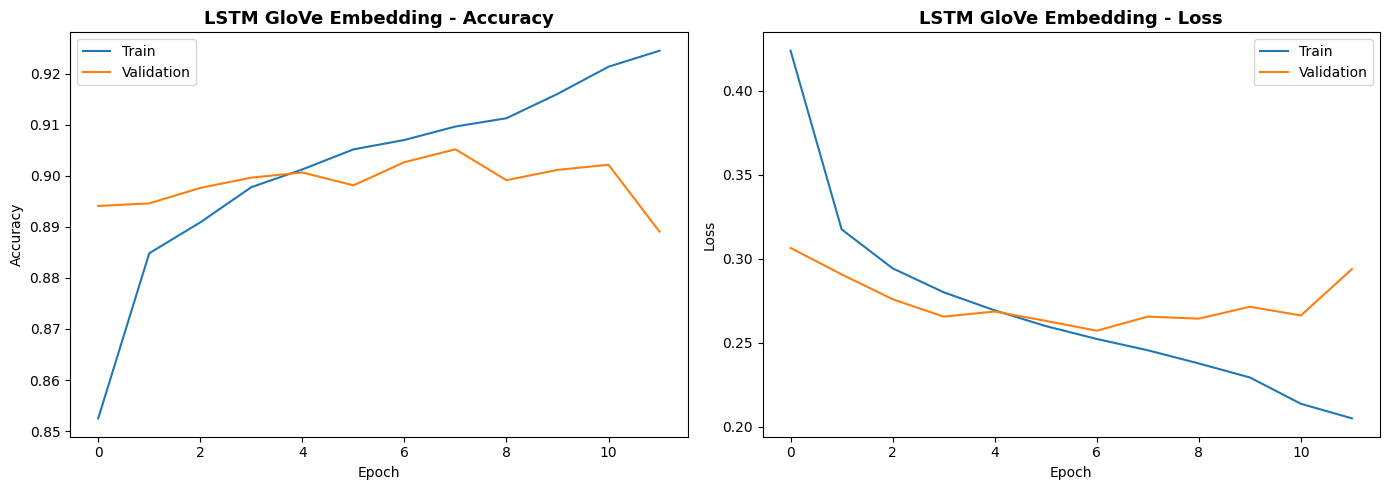

155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Evaluation Report : LSTM GloVe Embedding
Test Accuracy     : 89.91%
                    precision    recall  f1-score   support

        hate speec       0.51      0.29      0.37       286
           neither       0.80      0.91      0.85       833
offensive language       0.94      0.94      0.94      3838

          accuracy                           0.90      4957
         macro avg       0.75      0.71      0.72      4957
      weighted avg       0.89      0.90      0.89      4957



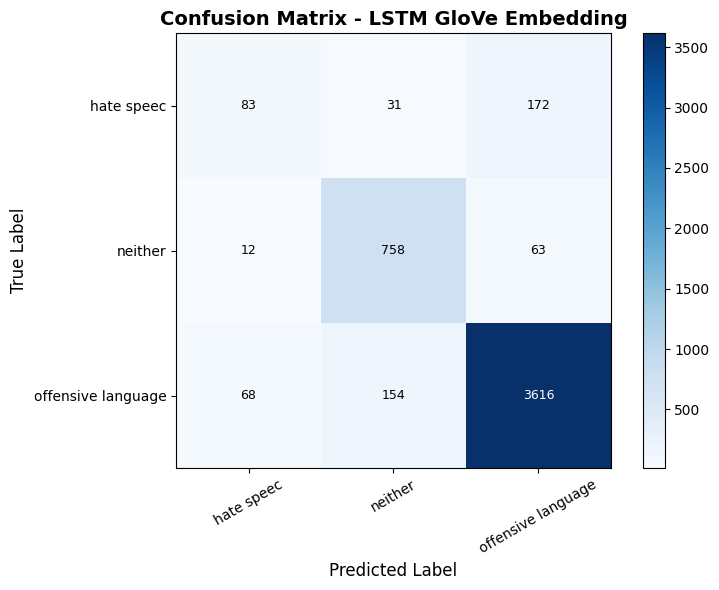

LSTM GloVe model saved


In [ ]:
start_time         = time.time()
history_lstm_glove = model_lstm_glove.fit(
    X_train_pad, y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)
lstm_glove_time = time.time() - start_time

print(f'LSTM GloVe training time : {lstm_glove_time:.1f} seconds')
plot_history(history_lstm_glove, 'LSTM GloVe Embedding')
y_pred_lstm_glove, acc_lstm_glove = evaluate_model(
    model_lstm_glove, X_test_pad, y_test, classes, 'LSTM GloVe Embedding')
model_lstm_glove.save('model_lstm_glove.h5')
print('LSTM GloVe model saved')

Model Comparison Plot

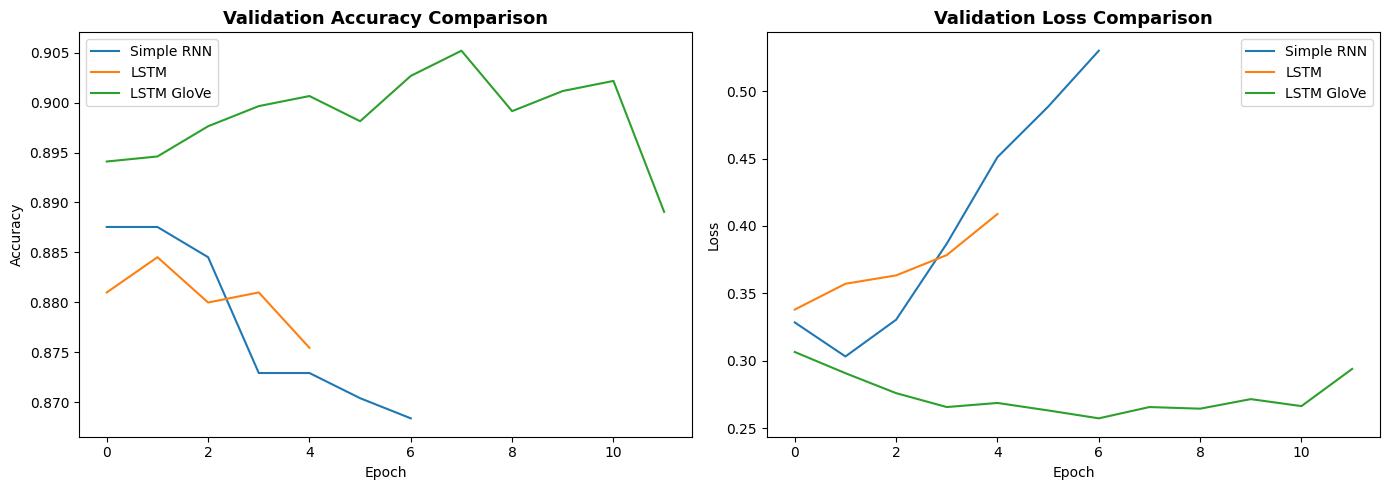

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_rnn.history['val_accuracy'],        label='Simple RNN')
axes[0].plot(history_lstm.history['val_accuracy'],       label='LSTM')
axes[0].plot(history_lstm_glove.history['val_accuracy'], label='LSTM GloVe')
axes[0].set_title('Validation Accuracy Comparison',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history_rnn.history['val_loss'],        label='Simple RNN')
axes[1].plot(history_lstm.history['val_loss'],       label='LSTM')
axes[1].plot(history_lstm_glove.history['val_loss'], label='LSTM GloVe')
axes[1].set_title('Validation Loss Comparison',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('model_comparison_curves.png', dpi=150)
plt.show()

Final Comparison Bar Chart

Final Model Comparison
  Simple RNN           : 88.32%
  LSTM                 : 88.18%
  LSTM GloVe           : 89.91%


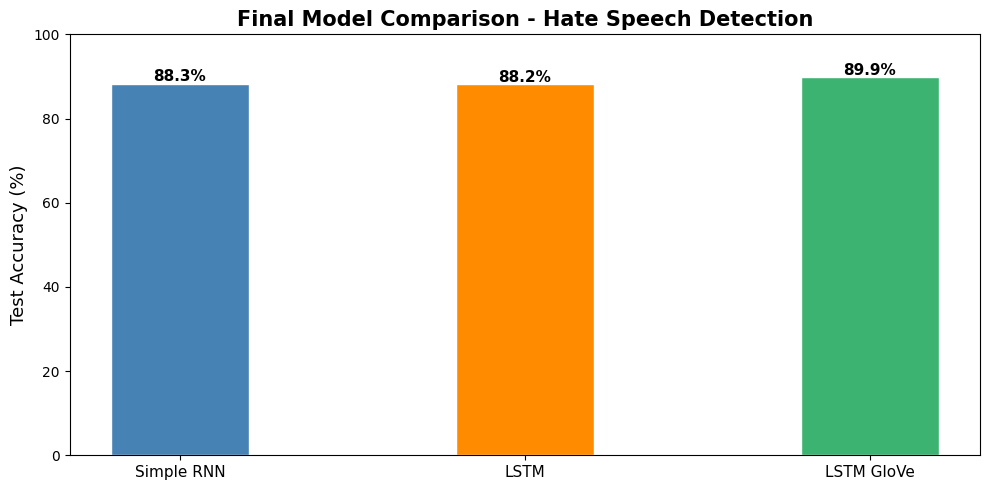

In [ ]:
summary = {
    'Simple RNN' : acc_rnn,
    'LSTM'       : acc_lstm,
    'LSTM GloVe' : acc_lstm_glove,
}

print('Final Model Comparison')
for name, acc in summary.items():
    print(f'  {name:<20} : {acc * 100:.2f}%')

fig, ax = plt.subplots(figsize=(10, 5))
colors  = ['steelblue', 'darkorange', 'mediumseagreen']
bars    = ax.bar(
    summary.keys(),
    [v * 100 for v in summary.values()],
    color=colors, width=0.4, edgecolor='white'
)

for bar, acc in zip(bars, summary.values()):
    ax.text(
        bar.get_x() + bar.get_width() / 2.0,
        bar.get_height() + 0.5,
        f'{acc * 100:.1f}%',
        ha='center', fontsize=11, fontweight='bold'
    )

ax.set_ylabel('Test Accuracy (%)', fontsize=13)
ax.set_title('Final Model Comparison - Hate Speech Detection',
             fontsize=15, fontweight='bold')
ax.set_ylim(0, 100)
plt.xticks(fontsize=11)
plt.tight_layout()
plt.savefig('final_comparison_nlp.png', dpi=150)
plt.show()

Gradio GUI

In [ ]:
import gradio as gr

def predict_text(text):
    cleaned    = clean_text(text)
    sequence   = tokenizer.texts_to_sequences([cleaned])
    padded     = pad_sequences(sequence, maxlen=MAX_LEN,
                               padding='post', truncating='post')
    pred       = model_lstm_glove.predict(padded, verbose=0)
    label_idx  = np.argmax(pred[0])
    label      = classes[label_idx]
    confidence = float(pred[0][label_idx]) * 100
    return f'Prediction : {label}  |  Confidence : {confidence:.1f}%'

interface = gr.Interface(
    fn=predict_text,
    inputs=gr.Textbox(lines=3, placeholder='Enter text here...'),
    outputs=gr.Textbox(label='Prediction'),
    title='Hate Speech Detection',
    description='Enter any text to classify it as hate, offensive, or neither.'
)

interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2e8fff33228d3ab562.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
